# Análisis Exploratorio (EDA)

## A. Descripción del dataset
- Nombre del dataset
- Fuente (Kaglle ASL Alphabet)
- Número total de imágenes
- Número de clases (29)
    - Letras A-Z
    - SPACE
    - DELETE
    - NOTHING
- Resolución original
    - 200 x 200 px
- Formato
    - JPG
- Organización
    - Una carpeta por clase

## B. Mostrar ejemplos de imágenes
- Al menos 5 letras distintas
- Varias imágenes de una misma letra para observar la variabilidad.

## C. Distribución de clases
- ¿Está balanceado?
- ¿Hay clases con menos imágenes?
- ¿Habrá sesgo?

## D. Resolución y formato
- ¿Todas las imágenes tienen el mismo tamaño?
- ¿Todas están en RGB?
- ¿Hay imágenes corruptas?
- ¿El formato es JPG?

## E. Letras visualmente similares
- M
- N
- S
y
- U
- V
- R

## F. División del dataset

## G Hallazgos


In [13]:
from pathlib import Path
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import cv2
import numpy as np

train_path = Path("data/asl_alphabet_train/asl_alphabet_train")

classes = sorted([d.name for d in train_path.iterdir() if d.is_dir()])

print(classes)
print(len(classes))

counts = {}

for folder in classes:
    counts[folder] = len(list((train_path / folder).glob("*.jpg")))

counts

df = pd.DataFrame({
    "Clase": counts.keys(),
    "Cantidad": counts.values()
})

df


['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
29


,Clase,Cantidad
0,A,3000
1,B,3000
2,C,3000
3,D,3000
4,E,3000
5,F,3000
6,G,3000
7,H,3000
8,I,3000
9,J,3000


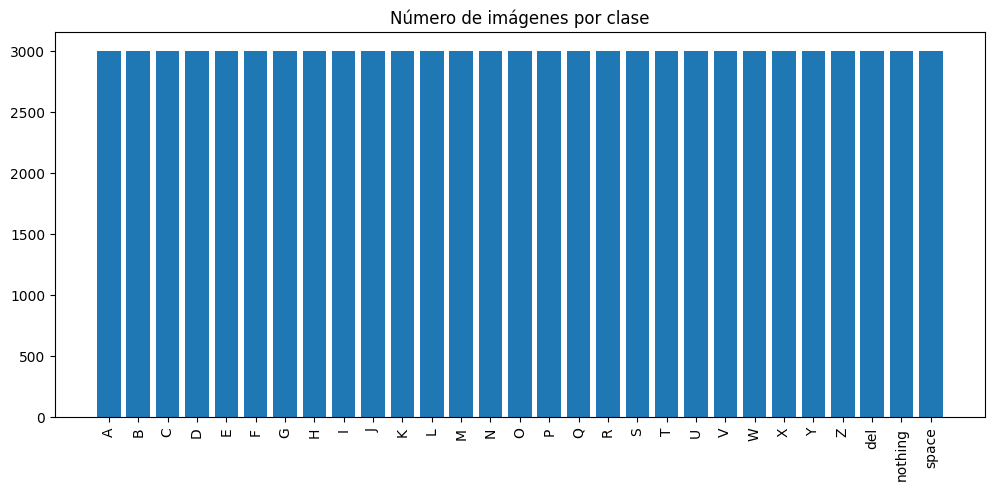

(200, 200)
RGB
JPEG


In [2]:
# Graficar la distribución
plt.figure(figsize=(12,5))

plt.bar(df["Clase"], df["Cantidad"])

plt.xticks(rotation=90)

plt.title("Número de imágenes por clase")

plt.show()

img_path = next((train_path/"A").glob("*.jpg"))

img = Image.open(img_path)

print(img.size)
print(img.mode)
print(img.format)

Mostrando: data\asl_alphabet_train\asl_alphabet_train\A


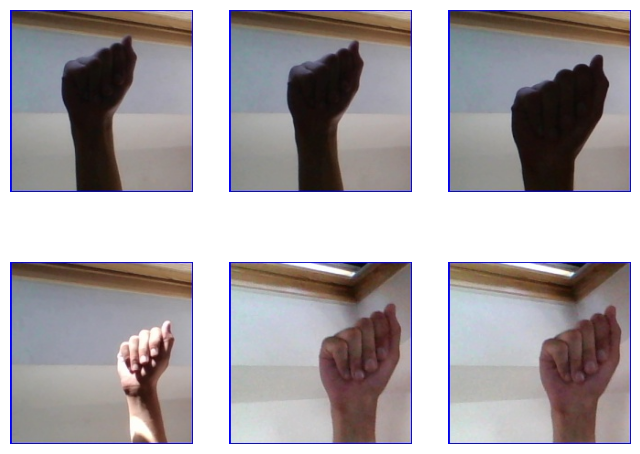

Mostrando: data\asl_alphabet_train\asl_alphabet_train\B


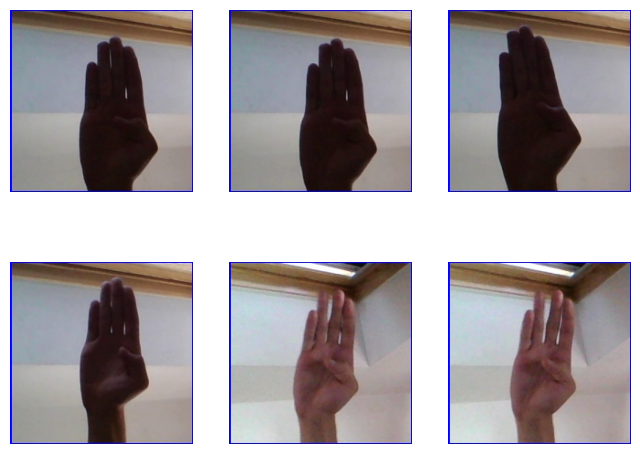

Mostrando: data\asl_alphabet_train\asl_alphabet_train\C


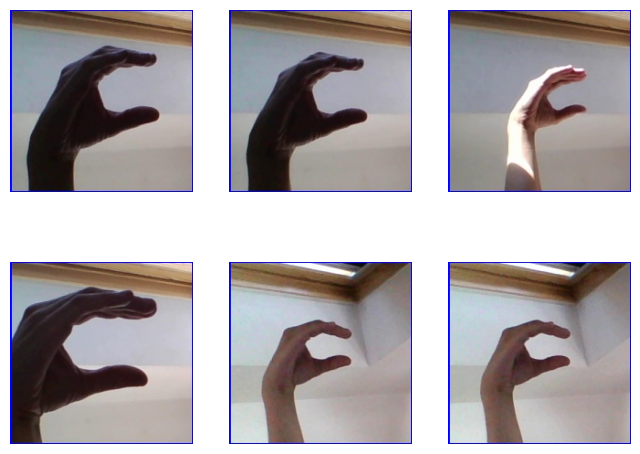

Mostrando: data\asl_alphabet_train\asl_alphabet_train\M


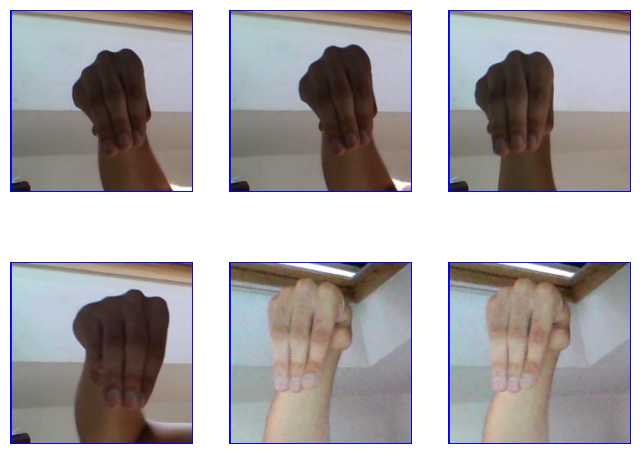

Mostrando: data\asl_alphabet_train\asl_alphabet_train\V


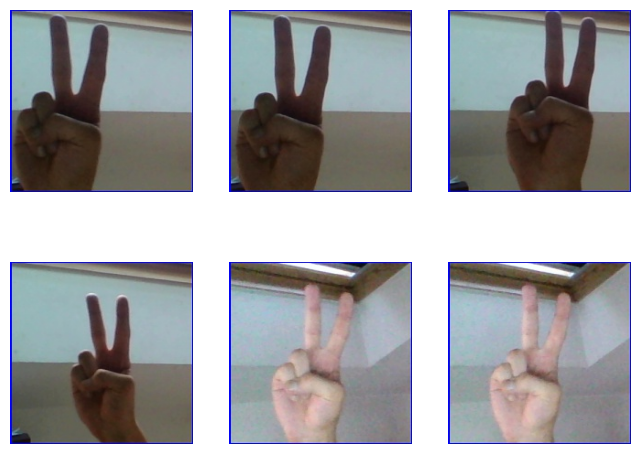

In [3]:
# Ver varias imágenes "A"
folder = train_path/"A"
print(f"Mostrando:", folder)

images = list(folder.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2,3, figsize=(8,6))

for ax, img_path in zip(axes.ravel(), images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.show()

# Para B
folder = train_path/"B"
print(f"Mostrando:", folder)

images = list(folder.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2,3, figsize=(8,6))

for ax, img_path in zip(axes.ravel(), images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.show()

# Para C
folder = train_path/"C"
print(f"Mostrando:", folder)

images = list(folder.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2,3, figsize=(8,6))

for ax, img_path in zip(axes.ravel(), images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.show()

# Para M
folder = train_path/"M"
print(f"Mostrando:", folder)

images = list(folder.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2,3, figsize=(8,6))

for ax, img_path in zip(axes.ravel(), images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.show()

# Para V
folder = train_path/"V"
print(f"Mostrando:", folder)

images = list(folder.glob("*.jpg"))[:6]

fig, axes = plt.subplots(2,3, figsize=(8,6))

for ax, img_path in zip(axes.ravel(), images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.show()

In [4]:
# Buscar imágenes dañadas
bad = []

for folder in classes:
    for file in (train_path/folder).glob("*.jpg"):
        try:
            Image.open(file).verify()
        except:
            bad.append(file)

print(len(bad))

0


In [5]:
# DataFrame con todas las imagenes

rows = []

for folder in classes:

    for file in (train_path/folder).glob("*.jpg"):

        rows.append({
            "label": folder,
            "path": str(file)
        })

images_df = pd.DataFrame(rows)

images_df.head()

,label,path
0,A,data\asl_alphabet_train\asl_alphabet_train\A\A...
1,A,data\asl_alphabet_train\asl_alphabet_train\A\A...
2,A,data\asl_alphabet_train\asl_alphabet_train\A\A...
3,A,data\asl_alphabet_train\asl_alphabet_train\A\A...
4,A,data\asl_alphabet_train\asl_alphabet_train\A\A...


In [8]:
# División de entrenamiento, validación y prueba
train_df, temp_df = train_test_split(
    images_df,
    test_size=0.30,
    stratify=images_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)